In [3]:
import nilearn as nl
import numpy as np
import matplotlib
import pandas as pd
import os
import nibabel as nib
import matplotlib.pyplot as plt
import openpyxl as xl

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
from nilearn.glm.first_level import FirstLevelModel
from nilearn.masking import compute_epi_mask, apply_mask, unmask
from nilearn.image import index_img, resample_to_img, math_img, mean_img, get_data
from nilearn.plotting import plot_stat_map, show
from nilearn import image, masking
from nilearn import plotting
from nilearn.datasets import load_mni152_brain_mask
from pandas import read_excel

from nilearn.glm.second_level import SecondLevelModel
from scipy.stats import norm

from nilearn.glm import threshold_stats_img

from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table

from atlasreader import create_output

In [4]:
#pip install atlasreader

## second level model

In [5]:
contrastImg_dir = "./testData/processed_first_level_MAC_family"

all_imgs = [
    os.path.join(contrastImg_dir, name) 
    for name in os.listdir(contrastImg_dir)
]

print(all_imgs)



['./testData/processed_first_level_MAC_family/212_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/243_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/234_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/095_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/221_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/207_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/229_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/190_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/127_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/200_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/226_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/251_contrast_macFamily.nii.gz', './testData/processed_first_level_MAC_family/208_contrast_macFamily.nii.gz'

In [6]:
second_level_input = all_imgs


In [7]:
# create a design matrix for one sample t test, to be used as input for the second level model
design_matrix = pd.DataFrame(
    [1] * len(second_level_input),
    columns=["intercept"],
)

In [8]:
design_matrix

,intercept
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,1


In [9]:
# set up group analysis for one sample t test on the contrast images
second_level_model = SecondLevelModel() 
second_level_model = second_level_model.fit(
    second_level_input,
    design_matrix=design_matrix,
)

In [10]:
# run one sample t test
z_map = second_level_model.compute_contrast(
    second_level_contrast="intercept",
    output_type="z_score",
) 

z_map.to_filename("SecondLevel_zscore_macFamily.nii.gz")

#output_type{‘z_score’, ‘stat’, ‘p_value’, ‘effect_size’, ‘effect_variance’, ‘all’},

#### fdr correction

In [11]:


thresholded_map, threshold = threshold_stats_img(
    stat_img=z_map,  # or p_map
    alpha=0.05,
    height_control='fdr',  # or 'bonferroni'
    cluster_threshold=10,   # min cluster size in voxels
    two_sided=True
)
print(f"The p<.05 FDR-corrected threshold is z score of {threshold:.3g}")

The p<.05 FDR-corrected threshold is z score of 3.06


In [12]:
# save as brain image
thresholded_map.to_filename("SecondLevel_fdrcorrect_macFamily.nii.gz")

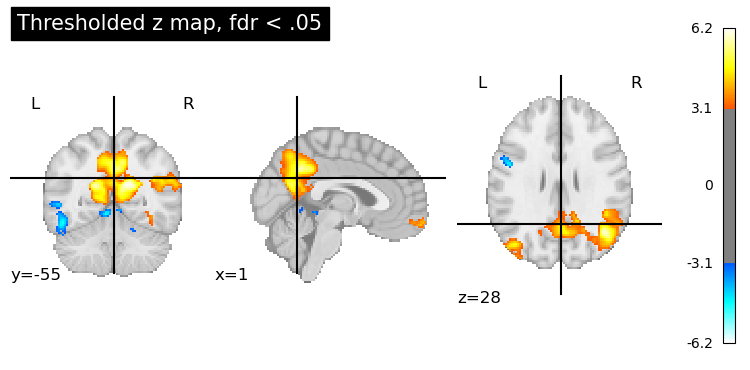

In [13]:
# quick visualization
plotting.plot_stat_map(
    thresholded_map,
    title="Thresholded z map, fdr < .05",
    threshold=threshold,
)

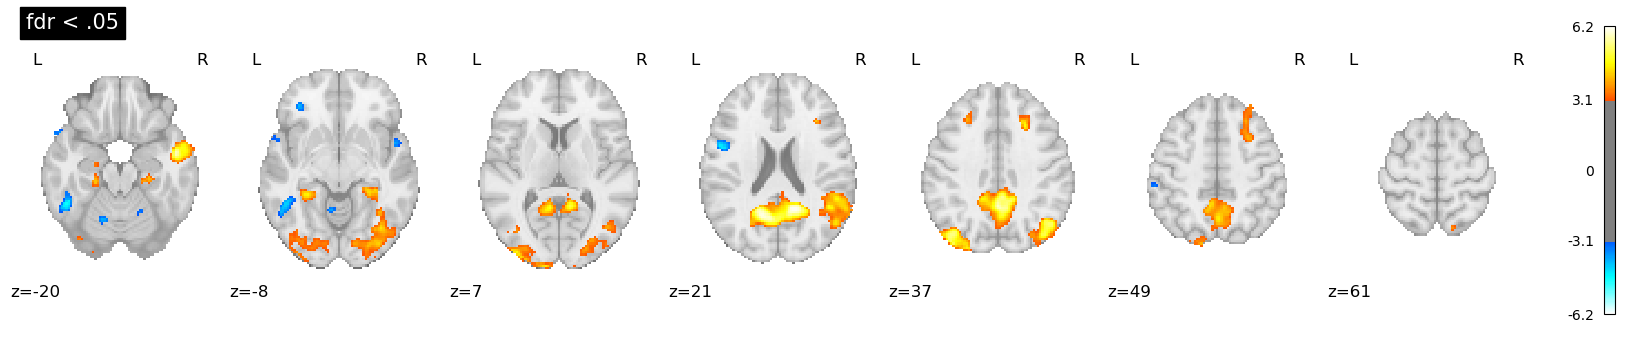

In [14]:
plotting.plot_stat_map(
    thresholded_map,
    threshold=threshold,
    display_mode="z",
    title="fdr < .05",
)


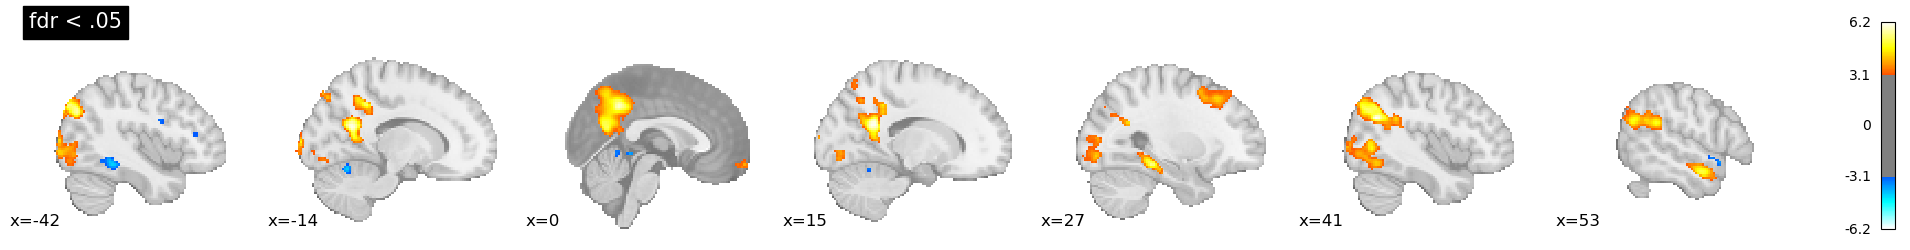

In [15]:
plotting.plot_stat_map(
    thresholded_map,
    threshold=threshold,
    display_mode="x",
    title="fdr < .05",
)

#### bonferroni correction

In [16]:
thresholded_map2, threshold2 = threshold_stats_img(
    z_map, alpha=0.05, height_control="bonferroni"
)
print(f"The p<.05 Bonferroni-corrected threshold is z score of {threshold2:.3g}")

The p<.05 Bonferroni-corrected threshold is z score of 5.22


In [17]:
# save as brain image
thresholded_map2.to_filename("SecondLevel_bonfcorrect_macFamily.nii.gz")

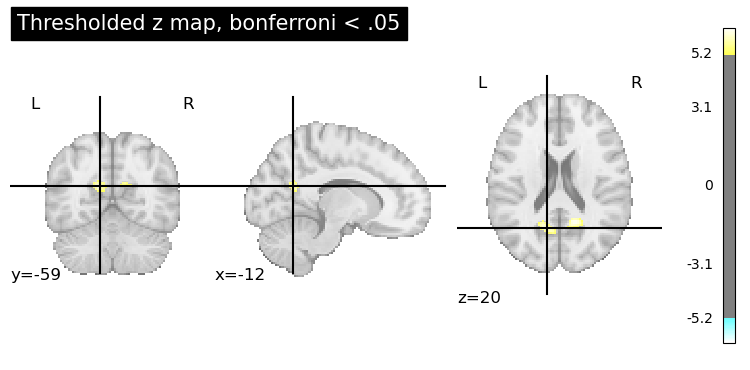

In [18]:
# quick visualization
plotting.plot_stat_map(
    thresholded_map2,
    title="Thresholded z map, bonferroni < .05",
    threshold=threshold2,
)

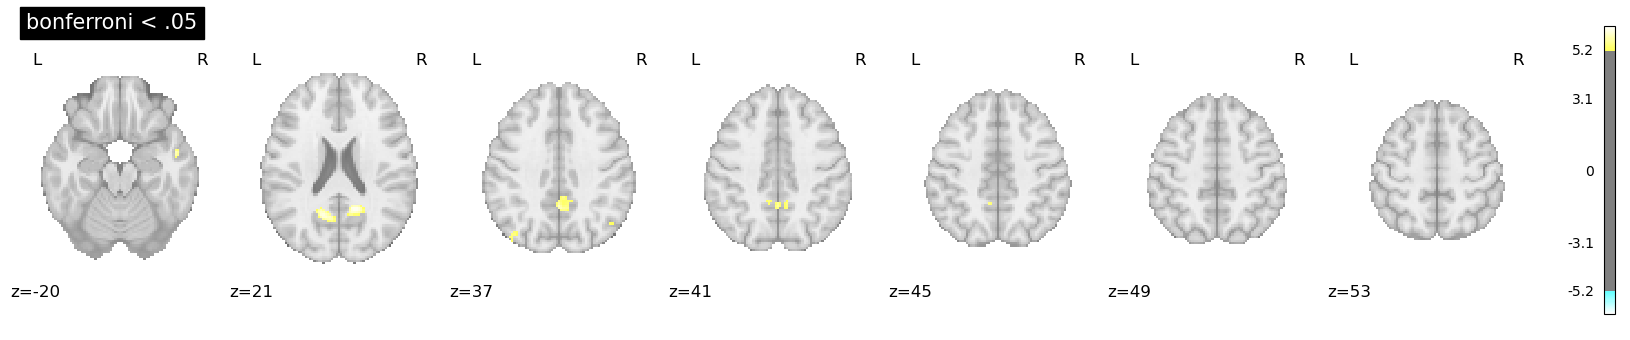

In [19]:
# quick visualization
plotting.plot_stat_map(
    thresholded_map2,
    title="bonferroni < .05",
    threshold=threshold2,
    display_mode = 'z'
)

#### tables

In [24]:
table = get_clusters_table(
    thresholded_map, stat_threshold=threshold, cluster_threshold=10
)
table.set_index("Cluster ID", drop=True)

TypeError: get_clusters_table() got an unexpected keyword argument 'direction'

In [25]:
# above table only has MNI coordinates, atlasreader has also anatomical labels (on fdr correction results)

create_output(thresholded_map, cluster_extent=10, direction = 'pos')

/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
